# Replikasi Pipeline: Xception + PSO + Subspace KNN untuk Deteksi Kanker Kulit
Berdasarkan: Shah et al., *Explainable AI-Based Skin Cancer Detection Using CNN, Particle Swarm Optimization and Machine Learning*, J. Imaging 2024, 10, 332.

**Alur notebook**
1. Dataset ISIC 2018 (malignant vs benign, 2637 train / 660 test) dan HAM10000 (holdout, biner)
2. Augmentasi **hanya data latih** (asli + Gaussian blur σ=2 + rotasi ±180° + sharpen) → 10.548 citra
3. Xception (pretrained, dibekukan) + GAP → FC 1024 → Dropout 0.5 → FC 2 (softmax), split latih:validasi = 70:30
4. Jaringan dibekukan → ekstraksi 1024 fitur (keluaran FC 1024) dari seluruh data latih (80%)
5. PSO seleksi fitur dengan fitness KNN (k=5)
6. Subspace KNN dengan 5-fold cross-validation → uji pada test (20%) dan holdout HAM10000
7. Tabel metrik, confusion matrix, dan ROC

**Setup Kaggle**
- Accelerator: GPU (T4/P100). Internet: **ON** (untuk mengunduh bobot ImageNet Xception).
- Tambahkan dua dataset lewat *Add Input*: `fanconic/skin-cancer-malignant-vs-benign` dan `kmader/skin-cancer-mnist-ham10000`.

**Bagian yang TIDAK ditulis di paper (asumsi saya, ubah di sel konfigurasi jika perlu)**: jumlah partikel PSO, bobot α fitness, pengkodean posisi PSO, aktivasi FC 1024 (ReLU), jumlah pembelajar dan dimensi subruang Subspace KNN, ukuran resize.

**Dua catatan metodologis penting**
- `LEAK_FREE=False` meniru paper: augmentasi dilakukan *sebelum* split 70:30, sehingga hasil augmentasi dari citra yang sama bisa jatuh di latih dan validasi (angka validasi/CV menjadi optimistis). Set `LEAK_FREE=True` untuk split per citra asli.
- HAM10000 adalah data latih ISIC 2018 Task 3, jadi ada kemungkinan overlap dengan dataset ISIC. Sel pengecekan duplikat (dHash) disediakan; hasil holdout juga dilaporkan tanpa near-duplicate.

## 1. Import dan konfigurasi

In [1]:
import os, glob, random, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter
from concurrent.futures import ThreadPoolExecutor
from tqdm.auto import tqdm

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     StratifiedGroupKFold, cross_val_predict)
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, matthews_corrcoef

warnings.filterwarnings("ignore")

# ---------------- Konfigurasi ----------------
SEED        = 42
IMG_SIZE    = 224      # ukuran penyimpanan (dataset ISIC Kaggle aslinya 224x224)
NET_SIZE    = 299      # input native Xception (di-resize di dalam model)
BATCH_SIZE  = 16       # paper
LR          = 1e-4     # paper (Adam)
EPOCHS      = 5        # paper: maks 30, Exp.1 dihentikan manual di epoch 5
VAL_FRAC    = 0.30     # paper: 70:30 latih:validasi
LEAK_FREE   = False    # False = meniru paper (augment lalu split); True = split per citra asli

# PSO (Tabel 4 paper)
T_ITER      = 100
C1 = C2     = 2.5
V_MAX       = 7.0
W_MAX, W_MIN = 0.95, 0.35
FIT_K       = 5        # KNN k=5 sebagai fitness (paper)
# --- asumsi (tidak ada di paper) ---
N_PARTICLES  = 20
ALPHA        = 0.99    # Fit = ALPHA*(1-acc) + (1-ALPHA)*|S|/D ; ALPHA=1 -> murni akurasi
PSO_ENCODING = 'continuous'   # 'continuous' (x in [0,1], ambang 0.5) atau 'binary' (sigmoid)

# Subspace KNN (asumsi; samakan dengan panel hyperparameter MATLAB jika diketahui)
SKNN_L  = 30           # jumlah pembelajar
SKNN_M  = None         # dimensi subruang; None -> D'//2
SKNN_K  = 1            # k tiap pembelajar KNN
CV_FOLDS = 5

HAM_CHUNK     = 512
CHECK_OVERLAP = True   # cek near-duplicate ISIC vs HAM10000 (dHash)
HASH_THR      = 6      # jarak Hamming <= 6 dari 64 bit dianggap near-duplicate (heuristik)

CLASS_NAMES = ['benign', 'malignant']   # benign=0, malignant=1 (urutan alfabet, seperti MATLAB)

# random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
# for g in tf.config.list_physical_devices('GPU'):
#     tf.config.experimental.set_memory_growth(g, True)
# print("TF", tf.__version__, "| GPU:", tf.config.list_physical_devices('GPU'))

## 2. Menemukan dataset (ISIC 2018 malignant vs benign dan HAM10000)

In [2]:
INPUT = '/kaggle/input'

def find_isic_root():
    for root, dirs, _ in os.walk(INPUT):
        if {'train', 'test'} <= set(dirs) and \
           os.path.isdir(os.path.join(root, 'train', 'benign')) and \
           os.path.isdir(os.path.join(root, 'train', 'malignant')):
            return root
    raise FileNotFoundError("Dataset 'skin-cancer-malignant-vs-benign' tidak ditemukan di /kaggle/input")

ISIC_ROOT = find_isic_root()
print("ISIC root:", ISIC_ROOT)

def list_images(d):
    return sorted(p for p in glob.glob(os.path.join(d, '*'))
                  if p.lower().endswith(('.jpg', '.jpeg', '.png')))

def collect(split):
    paths, labels = [], []
    for ci, cn in enumerate(CLASS_NAMES):
        ps = list_images(os.path.join(ISIC_ROOT, split, cn))
        paths += ps; labels += [ci] * len(ps)
    return paths, np.array(labels, dtype=np.int32)

isic_train_paths, y_tr0 = collect('train')
isic_test_paths,  y_te  = collect('test')
print(f"ISIC train: {len(y_tr0)} (benign {np.sum(y_tr0==0)}, malignant {np.sum(y_tr0==1)})  | paper: 2637 (1440/1197)")
print(f"ISIC test : {len(y_te)} (benign {np.sum(y_te==0)}, malignant {np.sum(y_te==1)})  | paper: 660 (360/300)")

# ---------------- HAM10000 ----------------
meta_path = None
for root, _, files in os.walk(INPUT):
    if 'HAM10000_metadata.csv' in files:
        meta_path = os.path.join(root, 'HAM10000_metadata.csv'); break
assert meta_path is not None, "HAM10000_metadata.csv tidak ditemukan"
ham_root = os.path.dirname(meta_path)

ham_meta = pd.read_csv(meta_path)
BENIGN_DX, MALIGNANT_DX = ['bkl', 'df', 'nv', 'vasc'], ['akiec', 'bcc', 'mel']   # Tabel 3 paper
ham_meta['label'] = ham_meta['dx'].map({**{d: 0 for d in BENIGN_DX}, **{d: 1 for d in MALIGNANT_DX}})

ham_files = {}
for root, _, files in os.walk(ham_root):
    for f in files:
        if f.lower().endswith('.jpg'):
            ham_files.setdefault(os.path.splitext(f)[0], os.path.join(root, f))
ham_meta['path'] = ham_meta['image_id'].map(ham_files)
assert ham_meta['path'].notna().all() and ham_meta['label'].notna().all()
ham_meta = ham_meta.sort_values('image_id').reset_index(drop=True)
y_ham = ham_meta['label'].values.astype(np.int32)
print(f"HAM10000: {len(ham_meta)} citra (benign {np.sum(y_ham==0)}, malignant {np.sum(y_ham==1)})  | paper: 10015 (8061/1954)")
print(ham_meta['dx'].value_counts().to_dict())

ISIC root: /kaggle/input/datasets/fanconic/skin-cancer-malignant-vs-benign
ISIC train: 2637 (benign 1440, malignant 1197)  | paper: 2637 (1440/1197)
ISIC test : 660 (benign 360, malignant 300)  | paper: 660 (360/300)
HAM10000: 10015 citra (benign 8061, malignant 1954)  | paper: 10015 (8061/1954)
{'nv': 6705, 'mel': 1113, 'bkl': 1099, 'bcc': 514, 'akiec': 327, 'vasc': 142, 'df': 115}


## 3. Memuat citra ISIC

In [3]:
def load_img(p, size=IMG_SIZE):
    with Image.open(p) as im:
        im = im.convert('RGB')
        if im.size != (size, size):
            im = im.resize((size, size), Image.BILINEAR)
        return np.asarray(im, dtype=np.uint8)

def load_many(paths, desc=''):
    with ThreadPoolExecutor(8) as ex:
        return np.stack(list(tqdm(ex.map(load_img, paths), total=len(paths), desc=desc)))

X_tr0 = load_many(isic_train_paths, 'ISIC train')
X_te  = load_many(isic_test_paths,  'ISIC test')
print(X_tr0.shape, X_te.shape, X_tr0.dtype)

ISIC train:   0%|          | 0/2637 [00:00<?, ?it/s]

ISIC test:   0%|          | 0/660 [00:00<?, ?it/s]

(2637, 224, 224, 3) (660, 224, 224, 3) uint8


## 4. Augmentasi data latih (Sec. 3.1.3 paper)
Hanya data latih. Setiap citra asli menghasilkan 4 citra: **asli**, **Gaussian blur (σ=2)**, **rotasi acak ∈ [−180°, 180°]**, dan **sharpening (Amount=2, Radius=1, Threshold=0 → UnsharpMask percent=200, radius=1, threshold=0)**. Hasil: 2637 × 4 = 10.548 citra (5760 benign, 4788 malignant), sesuai Tabel 2.

Augmentasi:   0%|          | 0/2637 [00:00<?, ?it/s]

(10548, 224, 224, 3) | benign: 5760 malignant: 4788 | paper: 5760 / 4788


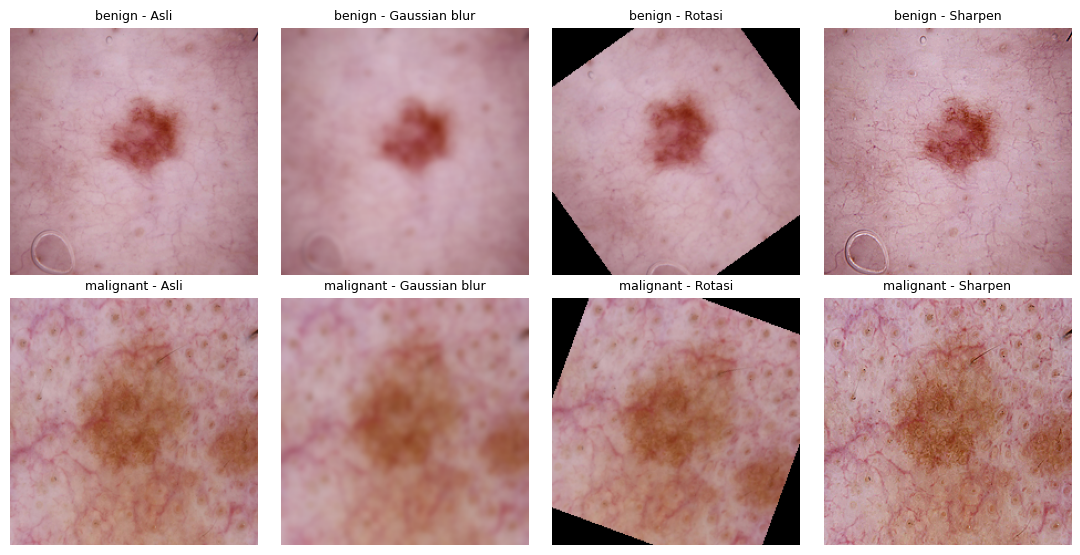

In [4]:
rng_aug = np.random.RandomState(SEED)

def aug_blur(a):    return np.asarray(Image.fromarray(a).filter(ImageFilter.GaussianBlur(radius=2)))
def aug_rotate(a):  return np.asarray(Image.fromarray(a).rotate(rng_aug.uniform(-180, 180), resample=Image.BILINEAR))
def aug_sharpen(a): return np.asarray(Image.fromarray(a).filter(ImageFilter.UnsharpMask(radius=1, percent=200, threshold=0)))

n0 = len(X_tr0)
X_aug = np.empty((4 * n0, IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8)
X_aug[:n0] = X_tr0
for i in tqdm(range(n0), desc='Augmentasi'):
    X_aug[n0 + i]     = aug_blur(X_tr0[i])
    X_aug[2 * n0 + i] = aug_rotate(X_tr0[i])
    X_aug[3 * n0 + i] = aug_sharpen(X_tr0[i])

y_aug   = np.tile(y_tr0, 4)
groups  = np.tile(np.arange(n0), 4)        # id citra asli (untuk split bebas-leak)
aug_typ = np.repeat(np.arange(4), n0)      # 0 asli, 1 blur, 2 rotasi, 3 sharpen
print(X_aug.shape, "| benign:", np.sum(y_aug == 0), "malignant:", np.sum(y_aug == 1), "| paper: 5760 / 4788")

fig, ax = plt.subplots(2, 4, figsize=(11, 5.6))
for r, cls in enumerate([0, 1]):
    i0 = int(np.where(y_tr0 == cls)[0][3])
    for c, nm in enumerate(['Asli', 'Gaussian blur', 'Rotasi', 'Sharpen']):
        ax[r, c].imshow(X_aug[c * n0 + i0]); ax[r, c].axis('off')
        ax[r, c].set_title(f"{CLASS_NAMES[cls]} - {nm}", fontsize=9)
plt.tight_layout(); plt.show()

## 5. Split latih : validasi = 70 : 30

In [5]:
if LEAK_FREE:
    g_tr, g_val = train_test_split(np.arange(n0), test_size=VAL_FRAC, stratify=y_tr0, random_state=SEED)
    in_tr = np.isin(groups, g_tr)
    idx_tr, idx_val = np.where(in_tr)[0], np.where(~in_tr)[0]
else:   # meniru paper: split atas 10.548 citra hasil augmentasi
    idx_tr, idx_val = train_test_split(np.arange(len(y_aug)), test_size=VAL_FRAC,
                                       stratify=y_aug, random_state=SEED)
idx_tr, idx_val = np.sort(idx_tr), np.sort(idx_val)
print(f"LEAK_FREE={LEAK_FREE} | latih {len(idx_tr)} | validasi {len(idx_val)} | test {len(y_te)}")
print("Citra asli yang sama muncul di latih & validasi:",
      len(set(groups[idx_tr]) & set(groups[idx_val])), "grup")

LEAK_FREE=False | latih 7383 | validasi 3165 | test 660
Citra asli yang sama muncul di latih & validasi: 1982 grup


## 6. Arsitektur CNN (Sec. 3.3 paper)
Xception pretrained (tanpa kepala klasifikasi) **dibekukan 100%** (ablation S2 paper) → **GAP → FC 1024 (ReLU, asumsi) → Dropout 0.5 → FC 2 (softmax)**.
Resize 224→299 dan normalisasi ke [−1, 1] (preprocessing standar Xception) dilakukan di dalam model.

In [6]:
def build_model():
    inp = keras.Input((IMG_SIZE, IMG_SIZE, 3), name='image')
    x = layers.Resizing(NET_SIZE, NET_SIZE, name='resize')(inp)
    x = layers.Rescaling(1 / 127.5, offset=-1, name='xception_preprocess')(x)
    base = keras.applications.Xception(include_top=False, weights='imagenet',
                                       input_shape=(NET_SIZE, NET_SIZE, 3))
    base.trainable = False                       # backbone dibekukan
    x = base(x, training=False)
    x = layers.GlobalAveragePooling2D(name='gap')(x)
    x = layers.Dense(1024, activation='relu', name='fc1024')(x)
    x = layers.Dropout(0.5, name='dropout')(x)
    out = layers.Dense(2, activation='softmax', name='softmax')(x)
    return keras.Model(inp, out, name='xception_skin')

model = build_model()
model.compile(optimizer=keras.optimizers.Adam(LR),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
trainable = int(sum(np.prod(w.shape) for w in model.trainable_weights))
total = model.count_params()
print(f"Parameter total {total:,} | dapat dilatih {trainable:,} (FC1024: 2048*1024+1024=2,098,176; FC2: 2,050)")

2026-10-07 09:43:55.403333: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Parameter total 22,961,706 | dapat dilatih 2,100,226 (FC1024: 2048*1024+1024=2,098,176; FC2: 2,050)


## 7. Training dengan softmax (Adam, lr=1e-4, batch 16, shuffle tiap epoch)

Epoch 1/5
    462/Unknown 1557s 3s/step - accuracy: 0.7492 - loss: 0.4969
Epoch 1: val_accuracy improved from None to 0.82275, saving model to best_head.weights.h5

Epoch 1: finished saving model to best_head.weights.h5
462/462 ━━━━━━━━━━━━━━━━━━━━ 2230s 5s/step - accuracy: 0.7903 - loss: 0.4367 - val_accuracy: 0.8227 - val_loss: 0.3928
Epoch 2/5
462/462 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8291 - loss: 0.3663
Epoch 2: val_accuracy improved from 0.82275 to 0.82970, saving model to best_head.weights.h5

Epoch 2: finished saving model to best_head.weights.h5
462/462 ━━━━━━━━━━━━━━━━━━━━ 2227s 5s/step - accuracy: 0.8358 - loss: 0.3552 - val_accuracy: 0.8297 - val_loss: 0.3508
Epoch 3/5
462/462 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.8585 - loss: 0.3157
Epoch 3: val_accuracy did not improve from 0.82970
462/462 ━━━━━━━━━━━━━━━━━━━━ 2196s 5s/step - accuracy: 0.8551 - loss: 0.3218 - val_accuracy: 0.7949 - val_loss: 0.4150
Epoch 4/5
462/462 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - acc

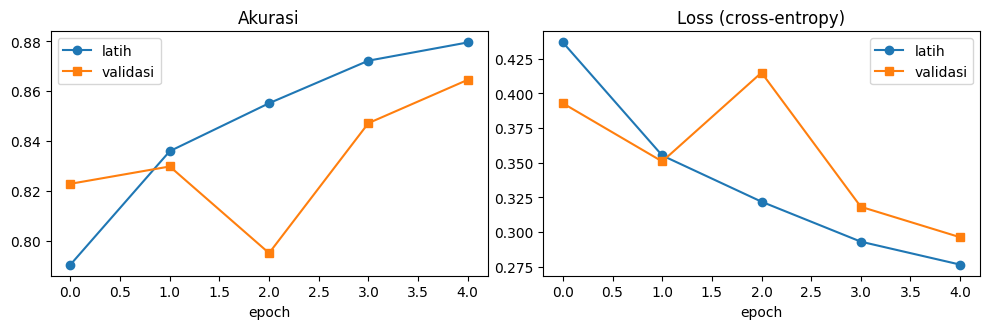

In [7]:
def make_ds(X, y, idx, batch, shuffle):
    def gen():
        ids = np.random.permutation(idx) if shuffle else idx
        for i in range(0, len(ids), batch):
            b = ids[i:i + batch]
            yield X[b].astype(np.float32), y[b].astype(np.int32)
    spec = (tf.TensorSpec((None, IMG_SIZE, IMG_SIZE, 3), tf.float32),
            tf.TensorSpec((None,), tf.int32))
    return tf.data.Dataset.from_generator(gen, output_signature=spec).prefetch(2)

train_ds = make_ds(X_aug, y_aug, idx_tr,  BATCH_SIZE, True)
val_ds   = make_ds(X_aug, y_aug, idx_val, BATCH_SIZE, False)

ckpt = keras.callbacks.ModelCheckpoint('best_head.weights.h5', monitor='val_accuracy',
                                       save_best_only=True, save_weights_only=True, verbose=1)
t0 = time.time()
hist = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS, callbacks=[ckpt], verbose=1)
print(f"Waktu training: {(time.time() - t0) / 60:.1f} menit")
model.load_weights('best_head.weights.h5')     # ambil epoch validasi terbaik

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].plot(hist.history['accuracy'], 'o-', label='latih'); ax[0].plot(hist.history['val_accuracy'], 's-', label='validasi')
ax[0].set_title('Akurasi'); ax[0].set_xlabel('epoch'); ax[0].legend()
ax[1].plot(hist.history['loss'], 'o-', label='latih'); ax[1].plot(hist.history['val_loss'], 's-', label='validasi')
ax[1].set_title('Loss (cross-entropy)'); ax[1].set_xlabel('epoch'); ax[1].legend()
plt.tight_layout(); plt.show()

## 8. Membekukan jaringan dan ekstraksi fitur
Seluruh jaringan dibekukan (`trainable=False`). Fitur = **keluaran FC 1024** (1024 fitur per citra). Ekstraksi dilakukan pada **seluruh data latih (80%, 10.548 citra)** dan data test (20%). Keluaran softmax ikut disimpan untuk evaluasi Eksperimen 1.

In [8]:
model.trainable = False
print("Parameter dapat dilatih setelah freeze:", len(model.trainable_weights))

multi = keras.Model(model.input, [model.get_layer('fc1024').output, model.output], name='feature_extractor')

def extract(X, idx=None, bs=64, desc=''):
    if idx is None: idx = np.arange(len(X))
    F, P = [], []
    for i in tqdm(range(0, len(idx), bs), desc=desc):
        f, p = multi.predict_on_batch(X[idx[i:i + bs]].astype(np.float32))
        F.append(np.asarray(f)); P.append(np.asarray(p))
    return np.concatenate(F).astype(np.float32), np.concatenate(P)

F_tr, P_tr = extract(X_aug, desc='Fitur train (aug)')
F_te, P_te = extract(X_te,  desc='Fitur test')
print("Matriks fitur latih:", F_tr.shape, "| test:", F_te.shape)
np.savez_compressed('features_isic.npz', F_tr=F_tr, y_aug=y_aug, groups=groups, F_te=F_te, y_te=y_te)

del X_aug      # bebaskan ~1.6 GB RAM
import gc; gc.collect()

# ---------------- wadah hasil ----------------
RESULTS = []
def record(exp, data, y, pred, score):
    RESULTS.append(dict(exp=exp, data=data, y=np.asarray(y), pred=np.asarray(pred), score=np.asarray(score)))

# Eksperimen 1: softmax CNN
record('Exp1: Xception + Softmax', 'ISIC validasi (30%)', y_aug[idx_val], P_tr[idx_val].argmax(1), P_tr[idx_val, 1])
record('Exp1: Xception + Softmax', 'ISIC test (20%)',     y_te,           P_te.argmax(1),          P_te[:, 1])
print(f"Exp1 akurasi validasi {np.mean(P_tr[idx_val].argmax(1) == y_aug[idx_val]):.4f} | test {np.mean(P_te.argmax(1) == y_te):.4f}")

Parameter dapat dilatih setelah freeze: 0


Fitur train (aug):   0%|          | 0/165 [00:00<?, ?it/s]

Fitur test:   0%|          | 0/11 [00:00<?, ?it/s]

Matriks fitur latih: (10548, 1024) | test: (660, 1024)
Exp1 akurasi validasi 0.8645 | test 0.8455


## 9. PSO seleksi fitur dengan fitness KNN (k=5)

**Rumus** (Kennedy & Eberhart 1995; inertia linear Shi & Eberhart 1998), untuk partikel $i$, dimensi $j$:

$$w_t = W_{max}-(W_{max}-W_{min})\,\frac{t}{T},\qquad v_{ij}\leftarrow w_t v_{ij}+c_1r_1(p_{ij}-x_{ij})+c_2r_2(g_j-x_{ij}),\; v_{ij}\in[-V_{max},V_{max}]$$
$$x_{ij}\leftarrow \mathrm{clip}(x_{ij}+v_{ij},0,1),\qquad b_{ij}=\mathbb 1[x_{ij}>0.5],\qquad S_i=\{j:b_{ij}=1\}$$
$$\text{Fit}(S)=\alpha\,(1-\mathrm{Acc}_{KNN,k=5}(S))+(1-\alpha)\,\frac{|S|}{D}\quad(\text{diminimalkan})$$

KNN fitness dilatih pada fitur latih (70%) dan dievaluasi pada fitur validasi (30%) dari split bagian 5, dihitung di GPU.

iter   1 | w=0.944 | gbest fit=0.13134 | acc KNN(k=5)=0.8724 | fitur=509
iter  10 | w=0.890 | gbest fit=0.12496 | acc KNN(k=5)=0.8787 | fitur=496
iter  20 | w=0.830 | gbest fit=0.12060 | acc KNN(k=5)=0.8831 | fitur=498
iter  30 | w=0.770 | gbest fit=0.11869 | acc KNN(k=5)=0.8850 | fitur=495
iter  40 | w=0.710 | gbest fit=0.11488 | acc KNN(k=5)=0.8888 | fitur=489
iter  50 | w=0.650 | gbest fit=0.11454 | acc KNN(k=5)=0.8891 | fitur=486
iter  60 | w=0.590 | gbest fit=0.11394 | acc KNN(k=5)=0.8897 | fitur=489
iter  70 | w=0.530 | gbest fit=0.11392 | acc KNN(k=5)=0.8897 | fitur=487
iter  80 | w=0.470 | gbest fit=0.11363 | acc KNN(k=5)=0.8900 | fitur=489
iter  90 | w=0.410 | gbest fit=0.11363 | acc KNN(k=5)=0.8900 | fitur=489
iter 100 | w=0.350 | gbest fit=0.11300 | acc KNN(k=5)=0.8907 | fitur=489

PSO selesai 24.7 menit | fitur terpilih 489 dari 1024 (paper: 508 dari 1024)


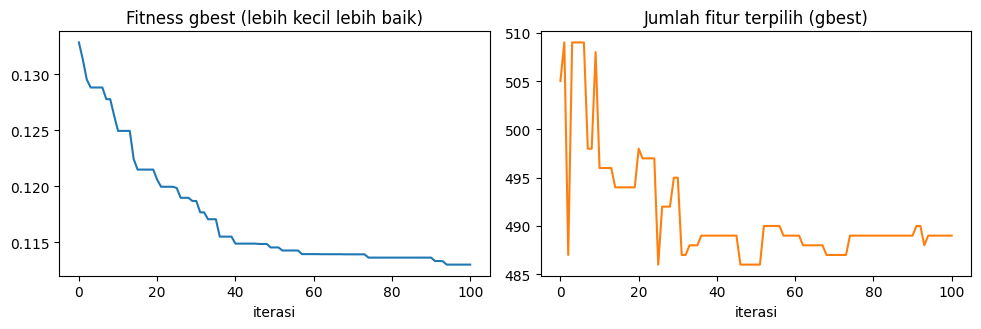

In [9]:
D = F_tr.shape[1]

class GPUKNN:
    """KNN (Euclidean, k ganjil, 2 kelas) dengan mask fitur - dihitung di GPU/CPU lewat TensorFlow."""
    def __init__(self, Ftr, ytr, Fva, yva, k=5):
        self.Ftr = tf.constant(Ftr, tf.float32); self.Fva = tf.constant(Fva, tf.float32)
        self.ytr = tf.constant(ytr, tf.int32);   self.yva = tf.constant(yva, tf.int32)
        self.k = k
    def accuracy(self, mask):
        m = tf.constant(mask.astype(np.float32))
        A, B = self.Fva * m, self.Ftr * m
        d = tf.reduce_sum(A * A, 1, keepdims=True) - 2.0 * tf.matmul(A, B, transpose_b=True) \
            + tf.reduce_sum(B * B, 1)[None, :]
        _, nn = tf.math.top_k(-d, k=self.k)
        votes = tf.reduce_sum(tf.gather(self.ytr, nn), axis=1)
        pred = tf.cast(votes * 2 > self.k, tf.int32)
        return float(tf.reduce_mean(tf.cast(pred == self.yva, tf.float32)))

knn_fit = GPUKNN(F_tr[idx_tr], y_aug[idx_tr], F_tr[idx_val], y_aug[idx_val], k=FIT_K)

def fitness_of(mask):
    nsel = int(mask.sum())
    if nsel == 0:
        return 1.0, 0.0
    acc = knn_fit.accuracy(mask)
    return ALPHA * (1 - acc) + (1 - ALPHA) * nsel / D, acc

def run_pso(n=N_PARTICLES, T=T_ITER, c1=C1, c2=C2, vmax=V_MAX, wmax=W_MAX, wmin=W_MIN,
            encoding=PSO_ENCODING, seed=SEED):
    rng = np.random.RandomState(seed)
    X = rng.uniform(0, 1, (n, D)) if encoding == 'continuous' else (rng.rand(n, D) < 0.5).astype(float)
    V = np.zeros((n, D))
    pfit = np.empty(n); pacc = np.empty(n)
    for i in range(n):
        pfit[i], pacc[i] = fitness_of(X[i] > 0.5)
    P = X.copy()
    gi = int(np.argmin(pfit)); G, gfit, gacc = P[gi].copy(), pfit[gi], pacc[gi]
    hist = [dict(iter=0, fit=gfit, acc=gacc, n_feat=int((G > 0.5).sum()))]
    for t in range(1, T + 1):
        w = wmax - (wmax - wmin) * t / T
        r1, r2 = rng.rand(n, D), rng.rand(n, D)
        V = np.clip(w * V + c1 * r1 * (P - X) + c2 * r2 * (G[None, :] - X), -vmax, vmax)
        if encoding == 'continuous':
            X = np.clip(X + V, 0.0, 1.0)
        else:
            X = (rng.rand(n, D) < 1.0 / (1.0 + np.exp(-V))).astype(float)
        for i in range(n):
            f, a = fitness_of(X[i] > 0.5)
            if f < pfit[i]:
                pfit[i], pacc[i], P[i] = f, a, X[i].copy()
        gi = int(np.argmin(pfit))
        if pfit[gi] < gfit:
            G, gfit, gacc = P[gi].copy(), pfit[gi], pacc[gi]
        hist.append(dict(iter=t, fit=gfit, acc=gacc, n_feat=int((G > 0.5).sum())))
        if t % 10 == 0 or t == 1:
            print(f"iter {t:3d} | w={w:.3f} | gbest fit={gfit:.5f} | acc KNN(k={FIT_K})={gacc:.4f} | fitur={hist[-1]['n_feat']}")
    return (G > 0.5), pd.DataFrame(hist)

t0 = time.time()
mask_sel, pso_hist = run_pso()
sel_idx = np.where(mask_sel)[0]
print(f"\nPSO selesai {(time.time() - t0) / 60:.1f} menit | fitur terpilih {len(sel_idx)} dari {D} (paper: 508 dari 1024)")
np.save('pso_selected_mask.npy', mask_sel)

fig, ax = plt.subplots(1, 2, figsize=(10, 3.4))
ax[0].plot(pso_hist['fit']); ax[0].set_title('Fitness gbest (lebih kecil lebih baik)'); ax[0].set_xlabel('iterasi')
ax[1].plot(pso_hist['n_feat'], color='tab:orange'); ax[1].set_title('Jumlah fitur terpilih (gbest)'); ax[1].set_xlabel('iterasi')
plt.tight_layout(); plt.show()

## 10. Subspace KNN (random subspace ensemble, Ho 1998)
$$P(c\mid x)=\frac1L\sum_{l=1}^{L}\frac1k\sum_{i\in\mathcal N_k^{(S_l)}(x)}\mathbb 1[y_i=c],\qquad \hat y=\arg\max_c P(c\mid x)$$
Tiap pembelajar $l$ memakai semua sampel latih tetapi hanya subset fitur $S_l$ ($|S_l|=m$, ditarik acak tanpa pengembalian). Implementasi sendiri di GPU, kompatibel dengan scikit-learn (`cross_val_predict`).

In [10]:
class SubspaceKNN(BaseEstimator, ClassifierMixin):
    def __init__(self, n_learners=30, subspace_dim=None, k=1, random_state=42, batch_size=1024):
        self.n_learners = n_learners; self.subspace_dim = subspace_dim
        self.k = k; self.random_state = random_state; self.batch_size = batch_size

    def fit(self, X, y):
        self.X_ = np.asarray(X, np.float32)
        self.classes_ = np.unique(y)
        self.y_idx_ = np.searchsorted(self.classes_, np.asarray(y)).astype(np.int32)
        Dd = self.X_.shape[1]
        m = self.subspace_dim or max(1, Dd // 2)
        rng = np.random.RandomState(self.random_state)
        self.subspaces_ = [np.sort(rng.choice(Dd, m, replace=False)) for _ in range(self.n_learners)]
        return self

    def predict_proba(self, X):
        X = np.asarray(X, np.float32); C = len(self.classes_)
        Xtr, ytr, Xq = tf.constant(self.X_), tf.constant(self.y_idx_, tf.int32), tf.constant(X)
        proba = np.zeros((len(X), C), np.float64)
        for S in self.subspaces_:
            S_t = tf.constant(S, tf.int32)
            Str = tf.gather(Xtr, S_t, axis=1); sq_tr = tf.reduce_sum(Str * Str, axis=1)
            Sq = tf.gather(Xq, S_t, axis=1)
            for i in range(0, len(X), self.batch_size):
                q = Sq[i:i + self.batch_size]
                d = tf.reduce_sum(q * q, 1, keepdims=True) - 2.0 * tf.matmul(q, Str, transpose_b=True) + sq_tr[None, :]
                _, nn = tf.math.top_k(-d, k=self.k)
                p = tf.reduce_mean(tf.one_hot(tf.gather(ytr, nn), C), axis=1)
                proba[i:i + self.batch_size] += p.numpy()
        return proba / len(self.subspaces_)

    def predict(self, X):
        return self.classes_[self.predict_proba(X).argmax(1)]

def new_sknn():
    return SubspaceKNN(n_learners=SKNN_L, subspace_dim=SKNN_M, k=SKNN_K, random_state=SEED)

if LEAK_FREE:
    cv = StratifiedGroupKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED); cv_groups = groups
else:
    cv = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED); cv_groups = None

def run_sknn(feat_idx, name):
    Ftr_s, Fte_s = F_tr[:, feat_idx], F_te[:, feat_idx]
    t0 = time.time()
    p_cv = cross_val_predict(new_sknn(), Ftr_s, y_aug, cv=cv, groups=cv_groups, method='predict_proba')
    record(name, f'ISIC CV {CV_FOLDS}-fold (latih)', y_aug, p_cv.argmax(1), p_cv[:, 1])
    clf = new_sknn().fit(Ftr_s, y_aug)
    p_te = clf.predict_proba(Fte_s)
    record(name, 'ISIC test (20%)', y_te, p_te.argmax(1), p_te[:, 1])
    print(f"{name}: CV acc {np.mean(p_cv.argmax(1) == y_aug):.4f} | test acc {np.mean(p_te.argmax(1) == y_te):.4f} | {time.time() - t0:.0f} dtk")
    return clf

clf_all = run_sknn(np.arange(D), 'Exp2*: Xception + Subspace KNN (semua fitur)')
clf_pso = run_sknn(sel_idx,      f'Exp3: Xception + PSO({len(sel_idx)}) + Subspace KNN')

Exp2*: Xception + Subspace KNN (semua fitur): CV acc 0.9067 | test acc 0.8485 | 59 dtk
Exp3: Xception + PSO(489) + Subspace KNN: CV acc 0.9095 | test acc 0.8621 | 40 dtk


## 11. Holdout HAM10000 (benign: bkl, df, nv, vasc; malignant: akiec, bcc, mel)
HAM10000 tidak dipakai untuk melatih apa pun (CNN, PSO, maupun Subspace KNN). Citra diproses per potongan agar hemat RAM. Di sini juga dihitung dHash untuk mendeteksi near-duplicate terhadap data ISIC.

In [11]:
def dhash(a):
    g = Image.fromarray(a).convert('L').resize((9, 8), Image.LANCZOS)
    v = np.asarray(g, dtype=np.int16)
    bits = (v[:, 1:] > v[:, :-1]).astype(np.uint8).flatten()
    return np.packbits(bits).view(np.uint64)[0]

POP = np.array([bin(i).count('1') for i in range(256)], dtype=np.uint8)
def min_hamming(A, B):
    out = np.empty(len(A), np.int32)
    for i in range(0, len(A), 256):
        x = np.bitwise_xor(A[i:i + 256, None], B[None, :])
        out[i:i + 256] = POP[x.view(np.uint8)].reshape(x.shape[0], x.shape[1], 8).sum(-1).min(1)
    return out

F_ham, P_ham, h_ham = [], [], []
paths = ham_meta['path'].tolist()
for s in tqdm(range(0, len(paths), HAM_CHUNK), desc='HAM10000'):
    Xc = load_many(paths[s:s + HAM_CHUNK])
    f, p = extract(Xc)
    F_ham.append(f); P_ham.append(p)
    if CHECK_OVERLAP: h_ham += [dhash(a) for a in Xc]
    del Xc
F_ham, P_ham = np.concatenate(F_ham), np.concatenate(P_ham)
print("Fitur HAM10000:", F_ham.shape)

dup_mask = np.zeros(len(y_ham), bool)
if CHECK_OVERLAP:
    h_isic = np.array([dhash(a) for a in np.concatenate([X_tr0, X_te])], dtype=np.uint64)
    dist = min_hamming(np.array(h_ham, dtype=np.uint64), h_isic)
    dup_mask = dist <= HASH_THR
    print(f"Near-duplicate HAM10000 vs ISIC (Hamming <= {HASH_THR}): {dup_mask.sum()} dari {len(dup_mask)} citra "
          f"({100 * dup_mask.mean():.1f}%)  -> heuristik, bukan bukti pasti")

def eval_ham(name, pred, score):
    record(name, 'HAM10000 holdout (semua)', y_ham, pred, score)
    if dup_mask.any():
        k = ~dup_mask
        record(name, 'HAM10000 holdout (tanpa near-dup)', y_ham[k], pred[k], score[k])

eval_ham('Exp1: Xception + Softmax', P_ham.argmax(1), P_ham[:, 1])
p = clf_all.predict_proba(F_ham);           eval_ham('Exp2*: Xception + Subspace KNN (semua fitur)', p.argmax(1), p[:, 1])
p_ham_pso = clf_pso.predict_proba(F_ham[:, sel_idx]); eval_ham(f'Exp3: Xception + PSO({len(sel_idx)}) + Subspace KNN', p_ham_pso.argmax(1), p_ham_pso[:, 1])

HAM10000:   0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/512 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/512 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

...

  0%|          | 0/512 [00:00<?, ?it/s]

  0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/287 [00:00<?, ?it/s]

  0%|          | 0/5 [00:00<?, ?it/s]

Fitur HAM10000: (10015, 1024)
Near-duplicate HAM10000 vs ISIC (Hamming <= 6): 3959 dari 10015 citra (39.5%)  -> heuristik, bukan bukti pasti


## 12. Matriks pengukuran
Definisi (kelas positif = **malignant**, standar klinis):
$Acc=\frac{TP+TN}{TP+TN+FP+FN}$, $Sen=\frac{TP}{TP+FN}$, $Spe=\frac{TN}{TN+FP}$, $Pre=\frac{TP}{TP+FP}$, $F1=\frac{2\,Pre\cdot Sen}{Pre+Sen}$, Balanced Acc $=\frac{Sen+Spe}{2}$, MCC, dan AUC.

*Catatan:* label Sen/Spe pada confusion matrix paper tampak tidak konsisten dengan definisi di atas, jadi tabel kedua memakai **benign sebagai kelas positif** untuk perbandingan. `Exp2*` memakai Subspace KNN pada semua 1024 fitur (di paper Exp. 2 memakai classifier lain seperti Medium Gaussian SVM) sehingga ini pembanding "tanpa PSO" yang adil.

In [12]:
def compute_metrics(y, pred, score, pos=1):
    y, pred, score = np.asarray(y), np.asarray(pred), np.asarray(score)
    if pos == 0: y, pred, score = 1 - y, 1 - pred, 1 - score
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    dv = lambda a, b: a / b if b > 0 else np.nan
    sen, spe, pre = dv(tp, tp + fn), dv(tn, tn + fp), dv(tp, tp + fp)
    f1 = dv(2 * pre * sen, pre + sen)
    auc = roc_auc_score(y, score) if len(np.unique(y)) == 2 else np.nan
    return dict(N=len(y), Acc=(tp + tn) / len(y), Sen=sen, Spe=spe, Pre=pre, F1=f1,
                BalAcc=(sen + spe) / 2, MCC=matthews_corrcoef(y, pred), AUC=auc, TP=tp, TN=tn, FP=fp, FN=fn)

def build_table(pos):
    rows = []
    for r in RESULTS:
        m = compute_metrics(r['y'], r['pred'], r['score'], pos)
        rows.append({'Eksperimen': r['exp'], 'Data': r['data'], **m})
    df = pd.DataFrame(rows)
    for c in ['Acc', 'Sen', 'Spe', 'Pre', 'F1', 'BalAcc']: df[c] = (df[c] * 100).round(2)
    df['MCC'] = df['MCC'].round(4); df['AUC'] = df['AUC'].round(4)
    return df

pd.set_option('display.width', 250, 'display.max_columns', 30, 'display.max_colwidth', 60)
print("=== Kelas positif = MALIGNANT ===")
table_mal = build_table(1); display(table_mal)
print("\n=== Kelas positif = BENIGN (pembanding gaya paper) ===")
table_ben = build_table(0); display(table_ben)
table_mal.to_csv('metrics_malignant_positive.csv', index=False)
table_ben.to_csv('metrics_benign_positive.csv', index=False)

print("\nRingkasan paper (ISIC test, Exp3): Acc 98.5 | HAM10000 holdout: Acc 86.1, Sen 91.42, Spe 64.31")

=== Kelas positif = MALIGNANT ===


,Eksperimen,Data,N,Acc,Sen,Spe,Pre,F1,BalAcc,MCC,AUC,TP,TN,FP,FN
0,Exp1: Xception + Softmax,ISIC validasi (30%),3165,86.45,87.13,85.88,83.69,85.37,86.50,0.7281,0.9466,1252,1484,244,185
1,Exp1: Xception + Softmax,ISIC test (20%),660,84.55,87.00,82.50,80.56,83.65,84.75,0.6922,0.9344,261,297,63,39
2,Exp2*: Xception + Subspace KNN (semua fitur),ISIC CV 5-fold (latih),10548,90.67,89.70,91.48,89.74,89.72,90.59,0.8118,0.9534,4295,5269,491,493
3,Exp2*: Xception + Subspace KNN (semua fitur),ISIC test (20%),660,84.85,85.67,84.17,81.85,83.71,84.92,0.6963,0.9149,257,303,57,43
4,Exp3: Xception + PSO(489) + Subspace KNN,ISIC CV 5-fold (latih),10548,90.95,89.66,92.01,90.32,89.99,90.84,0.8173,0.9628,4293,5300,460,495
5,Exp3: Xception + PSO(489) + Subspace KNN,ISIC test (20%),660,86.21,85.33,86.94,84.49,84.91,86.14,0.7222,0.9210,256,313,47,44
6,Exp1: Xception + Softmax,HAM10000 holdout (semua),10015,73.89,83.32,71.60,41.56,55.46,77.46,0.4460,0.8475,1628,5772,2289,326
7,Exp1: Xception + Softmax,HAM10000 holdout (tanpa near-dup),6056,70.69,84.62,67.76,35.58,50.10,76.19,0.4031,0.8274,891,3390,1613,162
8,Exp2*: Xception + Subspace KNN (semua fitur),HAM10000 holdout (semua),10015,77.42,80.14,76.76,45.54,58.08,78.45,0.4749,0.8434,1566,6188,1873,388
9,Exp2*: Xception + Subspace KNN (semua fitur),HAM10000 holdout (tanpa near-dup),6056,72.49,72.74,72.44,35.71,47.90,72.59,0.3580,0.7790,766,3624,1379,287



=== Kelas positif = BENIGN (pembanding gaya paper) ===


,Eksperimen,Data,N,Acc,Sen,Spe,Pre,F1,BalAcc,MCC,AUC,TP,TN,FP,FN
0,Exp1: Xception + Softmax,ISIC validasi (30%),3165,86.45,85.88,87.13,88.92,87.37,86.50,0.7281,0.9466,1484,1252,185,244
1,Exp1: Xception + Softmax,ISIC test (20%),660,84.55,82.50,87.00,88.39,85.34,84.75,0.6922,0.9344,297,261,39,63
2,Exp2*: Xception + Subspace KNN (semua fitur),ISIC CV 5-fold (latih),10548,90.67,91.48,89.70,91.44,91.46,90.59,0.8118,0.9534,5269,4295,493,491
3,Exp2*: Xception + Subspace KNN (semua fitur),ISIC test (20%),660,84.85,84.17,85.67,87.57,85.84,84.92,0.6963,0.9149,303,257,43,57
4,Exp3: Xception + PSO(489) + Subspace KNN,ISIC CV 5-fold (latih),10548,90.95,92.01,89.66,91.46,91.74,90.84,0.8173,0.9628,5300,4293,495,460
5,Exp3: Xception + PSO(489) + Subspace KNN,ISIC test (20%),660,86.21,86.94,85.33,87.68,87.31,86.14,0.7222,0.9210,313,256,44,47
6,Exp1: Xception + Softmax,HAM10000 holdout (semua),10015,73.89,71.60,83.32,94.65,81.53,77.46,0.4460,0.8475,5772,1628,326,2289
7,Exp1: Xception + Softmax,HAM10000 holdout (tanpa near-dup),6056,70.69,67.76,84.62,95.44,79.25,76.19,0.4031,0.8274,3390,891,162,1613
8,Exp2*: Xception + Subspace KNN (semua fitur),HAM10000 holdout (semua),10015,77.42,76.76,80.14,94.10,84.55,78.45,0.4749,0.8434,6188,1566,388,1873
9,Exp2*: Xception + Subspace KNN (semua fitur),HAM10000 holdout (tanpa near-dup),6056,72.49,72.44,72.74,92.66,81.31,72.59,0.3580,0.7790,3624,766,287,1379



Ringkasan paper (ISIC test, Exp3): Acc 98.5 | HAM10000 holdout: Acc 86.1, Sen 91.42, Spe 64.31


## 13. Confusion matrix dan ROC

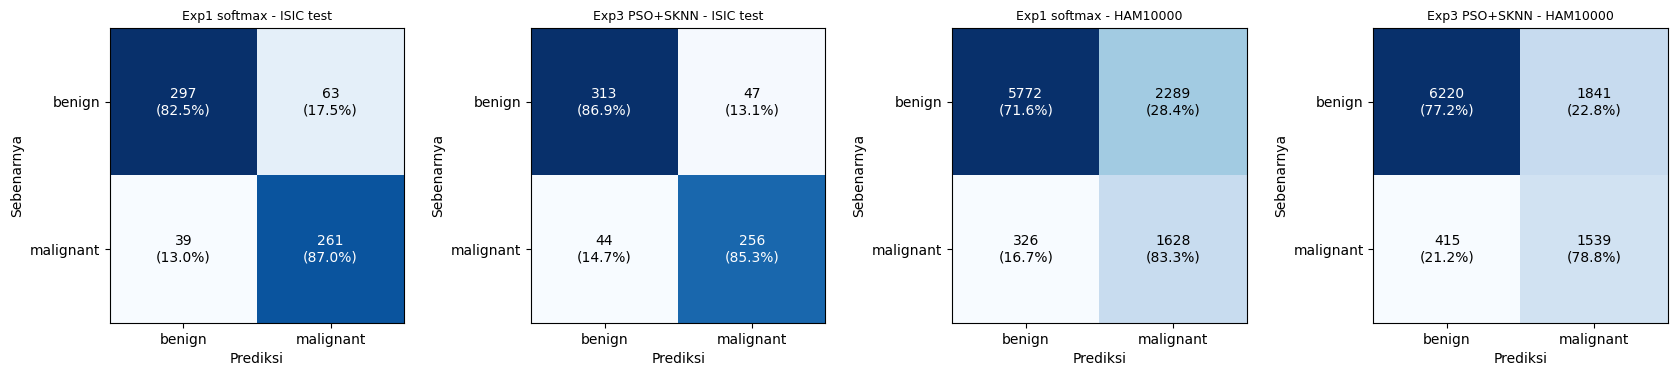

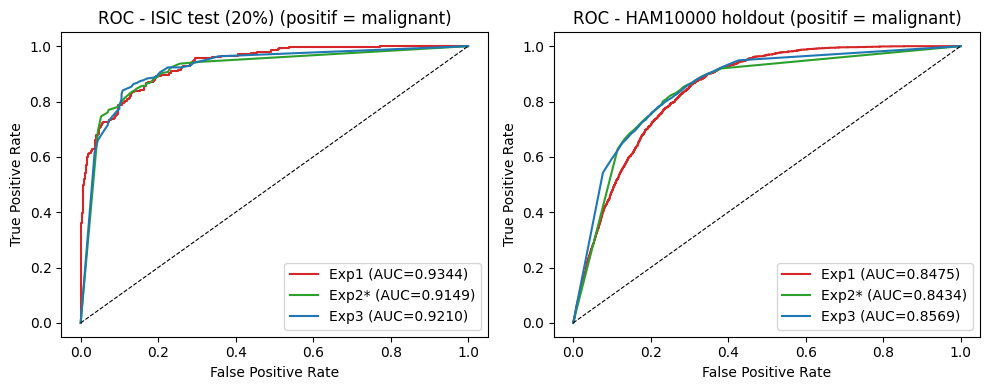

Tersimpan di /kaggle/working: bobot model, fitur ISIC, mask PSO, tabel metrik (CSV).


In [13]:
def get(exp_prefix, data_prefix):
    for r in RESULTS:
        if r['exp'].startswith(exp_prefix) and r['data'].startswith(data_prefix): return r
    return None

def plot_cm(ax, r, title):
    cm = confusion_matrix(r['y'], r['pred'], labels=[0, 1])
    ax.imshow(cm, cmap='Blues')
    for i in range(2):
        for j in range(2):
            ax.text(j, i, f"{cm[i, j]}\n({100 * cm[i, j] / cm[i].sum():.1f}%)", ha='center', va='center',
                    color='white' if cm[i, j] > cm.max() / 2 else 'black')
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1]); ax.set_xticklabels(CLASS_NAMES); ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel('Prediksi'); ax.set_ylabel('Sebenarnya'); ax.set_title(title, fontsize=9)

panels = [('Exp1', 'ISIC test', 'Exp1 softmax - ISIC test'),
          ('Exp3', 'ISIC test', 'Exp3 PSO+SKNN - ISIC test'),
          ('Exp1', 'HAM10000 holdout (semua)', 'Exp1 softmax - HAM10000'),
          ('Exp3', 'HAM10000 holdout (semua)', 'Exp3 PSO+SKNN - HAM10000')]
fig, axes = plt.subplots(1, 4, figsize=(17, 3.8))
for ax, (e, d, t) in zip(axes, panels):
    plot_cm(ax, get(e, d), t)
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, d, t in zip(axes, ['ISIC test', 'HAM10000 holdout (semua)'], ['ISIC test (20%)', 'HAM10000 holdout']):
    for e, c in [('Exp1', 'tab:red'), ('Exp2*', 'tab:green'), ('Exp3', 'tab:blue')]:
        r = get(e, d)
        fpr, tpr, _ = roc_curve(r['y'], r['score'])
        ax.plot(fpr, tpr, color=c, label=f"{r['exp'].split(':')[0]} (AUC={roc_auc_score(r['y'], r['score']):.4f})")
    ax.plot([0, 1], [0, 1], 'k--', lw=0.8); ax.set_title(f'ROC - {t} (positif = malignant)')
    ax.set_xlabel('False Positive Rate'); ax.set_ylabel('True Positive Rate'); ax.legend(loc='lower right')
plt.tight_layout(); plt.show()

model.save_weights('xception_skin_final.weights.h5')
print("Tersimpan di /kaggle/working: bobot model, fitur ISIC, mask PSO, tabel metrik (CSV).")